# Week 1 — Task 2: Trends, and the spaghetti problem

**Dataset:** `data/gapminder.csv` — 142 countries × 12 years (1952–2007, every 5 years). Columns:
`country`, `continent`, `year`, `lifeExp`, `pop`, `gdpPercap`.

> Run `python3 download_assignment_data.py` first, and run this notebook from the `assignments/` folder.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

# ---- House palette (same as the lecture) ---------------------------
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
YELLOW, MAGENTA = "#eda100", "#e87ba4"
GREEN, VIOLET, RED = "#008300", "#4a3aa7", "#e34948"
SERIES = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]

# Ink + surface colours. Text is NEVER the colour of the data.
INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID, SURFACE, QUIET = "#e6e5e1", "#fcfcfb", "#cfceca"

# ---- House style ---------------------------------------------------
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_SOFT,
        "axes.titlecolor": INK,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.titlepad": 14,
        "axes.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": INK_SOFT,
        "ytick.color": INK_SOFT,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.frameon": False,
        "legend.fontsize": 10,
        "lines.linewidth": 2,
        "font.size": 11,
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
    }
)


def save(fig, name):
    # Save every chart to charts/ so it can be dropped into slides.
    fig.savefig(CHARTS / f"{name}.png", facecolor=SURFACE)


def footnote(ax, text, y=-0.2):
    # One-line note under a chart: exclusions, sample sizes, caveats.
    ax.text(0, y, text, transform=ax.transAxes, fontsize=9, color=INK_MUTED)


print("Ready. pandas", pd.__version__)

Ready. pandas 3.0.2


## 1. Load and check the data

In [2]:
g = pd.read_csv(DATA / "gapminder.csv")
print("Rows:", g.shape[0], " Countries:", g["country"].nunique(), " Years:", g["year"].nunique())
print("Missing values:", int(g.isna().sum().sum()))
print("Rows per country (should all be 12):", sorted(g.groupby("country").size().unique()))
print()
print(g.groupby("continent")["country"].nunique().rename("countries").to_frame().T)
g.head()

Rows: 1704  Countries: 142  Years: 12
Missing values: 0
Rows per country (should all be 12): [np.int64(12)]

continent  Africa  Americas  Asia  Europe  Oceania
countries      52        25    33      30        2


,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106


Balanced panel, nothing missing, so **no rows are excluded from any chart** in this notebook. Note the
continent sizes: **Oceania has only 2 countries** (Australia and New Zealand), and Africa has 52. Keep
that in mind when reading continent averages.

## 2. Step 1 — make the messy chart on purpose

One line per country, all 142, with a legend.

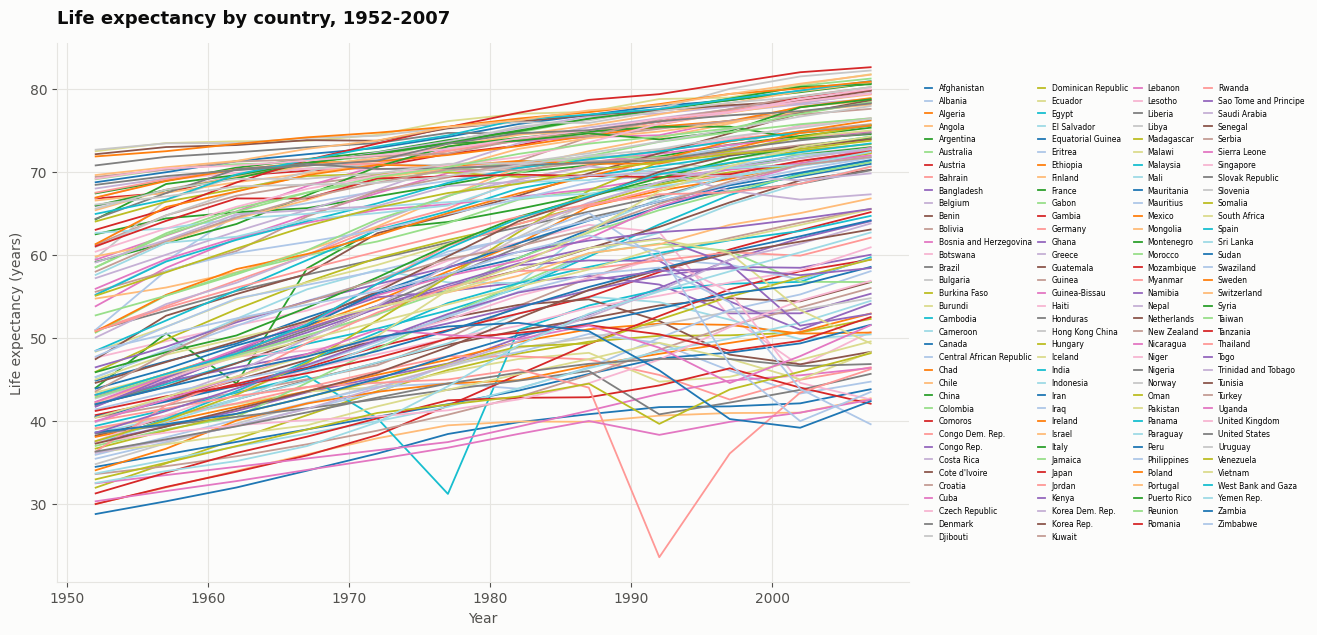

In [3]:
piv = g.pivot(index="year", columns="country", values="lifeExp")   # 12 rows x 142 countries

# ===================================================================
#  DELIBERATELY BAD CHART - an anti-example. Do not copy it.
# ===================================================================
fig, ax = plt.subplots(figsize=(11, 7))
colours = plt.cm.tab20(np.arange(piv.shape[1]) % 20)   # 142 lines, only 20 distinct colours
for colour, country in zip(colours, piv.columns):
    ax.plot(piv.index, piv[country], color=colour, linewidth=1.3, label=country)

ax.set_title("Life expectancy by country, 1952-2007")
ax.set_xlabel("Year")
ax.set_ylabel("Life expectancy (years)")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), ncol=4, fontsize=5.5,
          handlelength=1, columnspacing=0.8)
save(fig, "t2_spaghetti_bad")
plt.show()

### Everything wrong with it

1. **It has no message.** The title ("Life expectancy by country, 1952-2007") only repeats the axes. A
   reader cannot finish the sentence *"this chart shows that ____"*.
2. **Overplotting.** 142 lines cross and pile on top of each other in one band; you cannot follow any
   single line for more than a few years, and the middle of the chart is a solid tangle.
3. **The legend is unusable.** It has 142 entries in 5.5pt type and takes up more space than the data.
4. **The colours are meaningless, and repeated.** There are 142 lines but only 20 distinct colours, so
   about seven countries share each colour. Even if you could find "Rwanda" in the legend, you could not tell which
   of the several same-coloured lines is Rwanda's.
5. **Legend look-up is the wrong mechanism.** The reader has to match a colour in the legend to a line in
   the plot, hundreds of times over. Direct labels on the line remove that step entirely.
6. **The interesting lines are invisible.** Rwanda crashes to about 24 years in 1992 and Botswana falls by
   17 years between 1987 and 2002, but they look like every other line, so nothing draws the eye to them.
7. **Nothing is summarised.** All of the work of finding a pattern is left to the reader.

## 3. Step 2a — fix it by **aggregating**: one line per continent

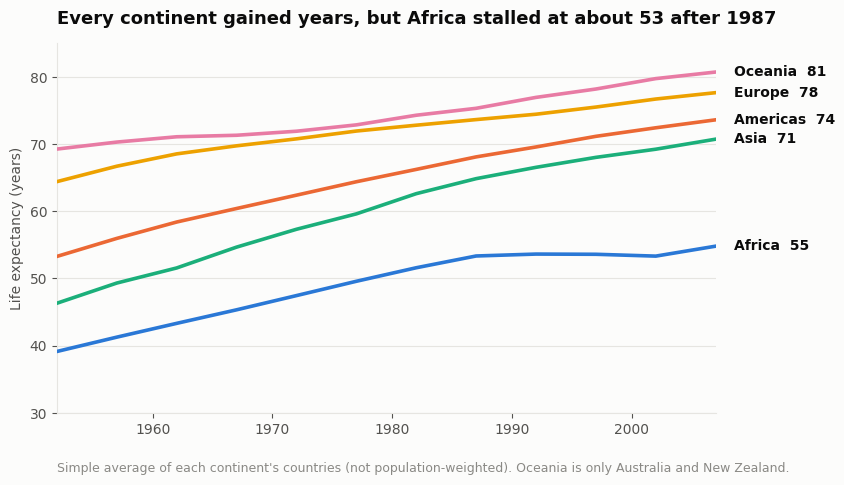

In [4]:
CONT = {"Africa": BLUE, "Americas": ORANGE, "Asia": AQUA, "Europe": YELLOW, "Oceania": MAGENTA}

cont = g.groupby(["continent", "year"])["lifeExp"].mean().reset_index()

fig, ax = plt.subplots(figsize=(8.5, 4.8))
for name, colour in CONT.items():
    s = cont[cont["continent"] == name]
    ax.plot(s["year"], s["lifeExp"], color=colour, linewidth=2.6, zorder=3)
    last = s.iloc[-1]
    # Direct label at the end of each line - no legend needed.
    ax.text(2008.5, last["lifeExp"], f"{name}  {last['lifeExp']:.0f}", va="center",
            color=INK, fontsize=10, fontweight="bold")

ax.set_title("Every continent gained years, but Africa stalled at about 53 after 1987")
ax.set_ylabel("Life expectancy (years)")
ax.set_xlim(1952, 2007)
ax.set_ylim(30, 85)
ax.xaxis.grid(False)
ax.set_axisbelow(True)
footnote(ax, "Simple average of each continent's countries (not population-weighted). "
             "Oceania is only Australia and New Zealand.", y=-0.16)

save(fig, "t2_continents")
plt.show()

In [5]:
# The small table behind the chart - if you can't write it down, you don't know what the chart says.
table = cont.pivot(index="year", columns="continent", values="lifeExp").round(1)
gain = (table.loc[2007] - table.loc[1952]).rename("gain 1952-2007")
africa_late = table.loc[[1987, 1992, 1997, 2002, 2007], "Africa"]
print(pd.concat([table.loc[[1952, 2007]].T, gain], axis=1))
print("\nAfrica, 1987 to 2007:", africa_late.tolist())

           1952  2007  gain 1952-2007
continent                            
Africa     39.1  54.8            15.7
Americas   53.3  73.6            20.3
Asia       46.3  70.7            24.4
Europe     64.4  77.6            13.2
Oceania    69.3  80.7            11.4

Africa, 1987 to 2007: [53.3, 53.6, 53.6, 53.3, 54.8]


**Why a line chart?** The question is *"how does life expectancy change over time?"*. Time is an
**ordered axis** and the steps between values (five years) are meaningful, so a **line** is the right
chart: the connecting line says *"read these points in order"*. I chose a line rather than bars because
the message is the *trajectory*, not the level in any one year. The five lines share a single y-axis,
each carries its own name on the end of the line, and the colour identifies the continent (which is the
only reason to use colour). The line ends carry the 2007 value, the only numbers worth reading directly.

## 4. Step 2b — fix it by **highlighting**: keep all 142, grey out all but 3

I picked three countries that tell three different stories:

- **China** — the largest climb of the three (44 → 73), with a visible dip in the early 1960s.
- **Botswana** — rose to 64 by 1987, then fell by 17 years by 2002.
- **Rwanda** — never got above about 46, and collapsed to 24 in 1992.

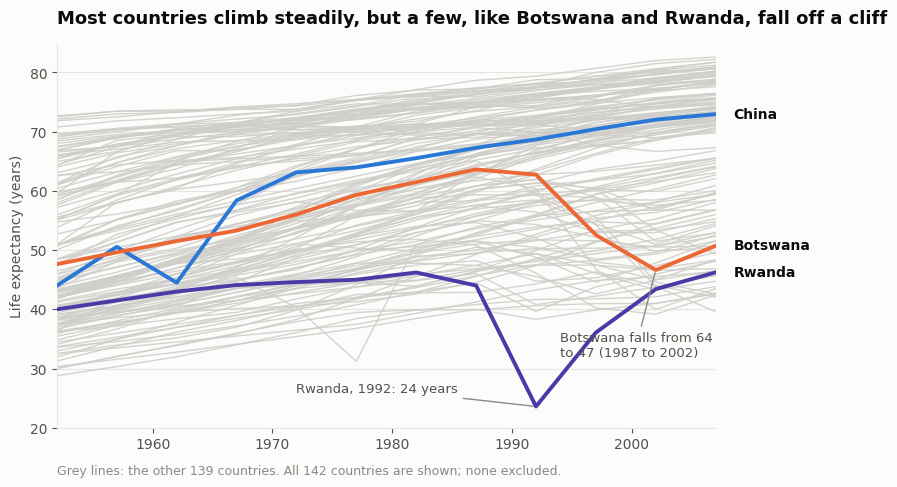

In [6]:
HL = {"China": BLUE, "Botswana": ORANGE, "Rwanda": VIOLET}

fig, ax = plt.subplots(figsize=(8.5, 5))
for country in piv.columns:
    if country not in HL:
        ax.plot(piv.index, piv[country], color=QUIET, linewidth=1, alpha=0.9, zorder=1)

for country, colour in HL.items():
    ax.plot(piv.index, piv[country], color=colour, linewidth=2.8, zorder=3)
    ax.text(2008.5, piv.loc[2007, country], country, va="center", color=INK,
            fontsize=10, fontweight="bold")

# Two selective annotations on the moments that carry the message.
ax.annotate("Rwanda, 1992: 24 years", (1992, piv.loc[1992, "Rwanda"]), xytext=(1972, 26),
            fontsize=9.5, color=INK_SOFT, arrowprops=dict(arrowstyle="-", color=INK_MUTED, lw=1))
ax.annotate("Botswana falls from 64\nto 47 (1987 to 2002)", (2002, piv.loc[2002, "Botswana"]),
            xytext=(1994, 32), fontsize=9.5, color=INK_SOFT,
            arrowprops=dict(arrowstyle="-", color=INK_MUTED, lw=1))

ax.set_title("Most countries climb steadily, but a few, like Botswana and Rwanda, fall off a cliff")
ax.set_ylabel("Life expectancy (years)")
ax.set_xlim(1952, 2007)
ax.set_ylim(20, 85)
ax.xaxis.grid(False)
ax.set_axisbelow(True)
footnote(ax, "Grey lines: the other 139 countries. All 142 countries are shown; none excluded.", y=-0.12)

save(fig, "t2_highlight")
plt.show()

**Why a line chart again, and why grey?** Same reasoning as before: the axis is time, so lines. The
difference is the *question*: here it is *"what do individual countries do, against the background of all
of them?"*. Keeping all 142 lines as a **grey background** preserves the overall shape (the crowd rises),
and the three coloured lines are the story. Colour is now used for **emphasis**, which is meaningful: it
says "look here". Labels sit directly on the lines with no legend, and only two moments are annotated.

## 5. Step 3 — compare (a) and (b)

| | **(a) Aggregate — one line per continent** | **(b) Highlight — 3 in colour, 139 grey** |
|---|---|---|
| **Can show** | The overall pattern at a glance; group differences (Asia gained 24 years, Europe 13); the **Africa plateau after 1987**; whether groups are converging. | Individual stories; the **spread within the crowd**; that specific countries **move against the trend**; how unusual an outlier really is. |
| **Cannot show** | Anything about individual countries. The Africa average hides both countries that kept rising and countries that collapsed. Averages of 2 countries (Oceania) look as solid as averages of 52. | A clean comparison *between groups*. Three hand-picked countries are anecdotes, not a summary, and **my choice of which three to colour is a bias**: pick three others and the chart says something different. |

They answer different questions. (a) answers *"what is the typical trend for each group?"*, and (b) answers
*"how do individual cases relate to the crowd?"*. (a) is what I would put in a summary report; (b)
is what I would use to open a discussion about *why* some countries diverge. Notice that (b) actually
**explains** (a): the reason Africa's average stalls is that some African countries reversed course while
others carried on rising, and only (b) can show you that.

## 6. Step 4 — has the gap between richest and poorest narrowed since 1952?

I read "gap between the richest and poorest countries" as a **gap in income** (`gdpPercap`). The watch-out
in the brief matters here: `gdpPercap` is extremely skewed. Let me look at it first.

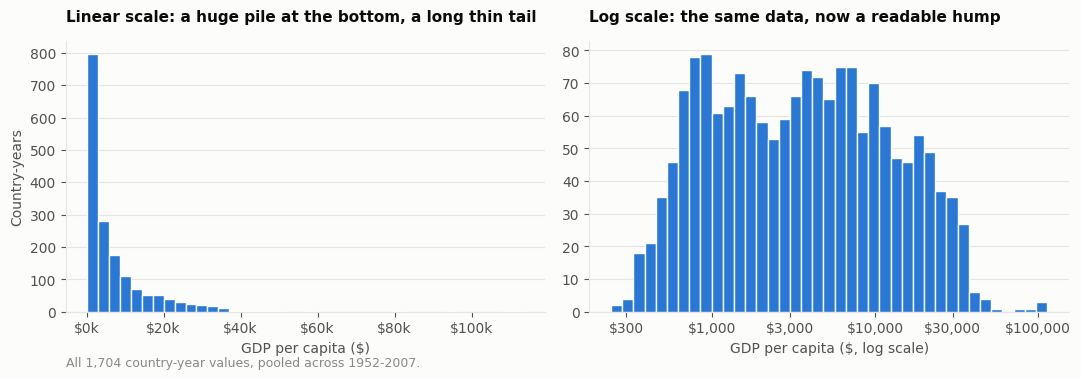

skewness (0 = symmetric): 3.85 -> after log10: 0.11


In [7]:
from matplotlib.ticker import NullLocator, NullFormatter

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(g["gdpPercap"], bins=40, color=BLUE, edgecolor=SURFACE, linewidth=1, zorder=3)
axes[0].set_title("Linear scale: a huge pile at the bottom, a long thin tail", fontsize=11)
axes[0].set_xlabel("GDP per capita ($)")
axes[0].set_ylabel("Country-years")
axes[0].xaxis.set_major_formatter(lambda v, p: f"${v/1000:.0f}k")

axes[1].hist(g["gdpPercap"], bins=np.logspace(np.log10(g["gdpPercap"].min()),
             np.log10(g["gdpPercap"].max()), 40), color=BLUE, edgecolor=SURFACE, linewidth=1, zorder=3)
axes[1].set_xscale("log")
axes[1].set_title("Log scale: the same data, now a readable hump", fontsize=11)
axes[1].set_xlabel("GDP per capita ($, log scale)")
axes[1].set_xticks([300, 1000, 3000, 10000, 30000, 100000])
axes[1].xaxis.set_major_formatter(lambda v, p: f"${v:,.0f}")
axes[1].xaxis.set_minor_locator(NullLocator())

for ax in axes:
    ax.set_axisbelow(True)
    ax.xaxis.grid(False)
footnote(axes[0], "All 1,704 country-year values, pooled across 1952-2007.", y=-0.2)
fig.tight_layout()
save(fig, "t2_gdp_hist_linear_vs_log")
plt.show()

print("skewness (0 = symmetric):", round(g["gdpPercap"].skew(), 2), "-> after log10:",
      round(np.log10(g["gdpPercap"]).skew(), 2))

**What a log scale does.** On the linear axis (left) the median country is about $3,500 but the chart
runs out to over $100,000, so nearly everything is squashed into the first two or three bars and the tail
is a handful of rich outliers. On the **log axis** (right) each step is a **multiple** (×3, ×10) rather
than a fixed dollar amount, and the same data unfolds into a broad, readable hump (skewness drops from
about 3.9 to about 0.1).

**Should I use a log scale for the gap question? Yes.** Income gaps are naturally about *ratios*: going
from $500 to $1,000 is a doubling for a poor country and matters as much as going from $16,000 to
$32,000 for a rich one. On a linear axis, a poor country's entire history would be a flat line hugging
zero next to a rich country's. On a log axis, **equal vertical distances mean equal ratios**, so
the vertical distance between two lines *is* the ratio between them, which is exactly "the gap" I want to read.

**Which countries define "richest" and "poorest"?** I do not use the single richest and poorest country,
because those are one-country noise. The richest in 1952 was **Kuwait ($108,000, an oil-driven outlier
seven times the next country)**, so a max-vs-min gap would be dominated by that one country. I use the **10th percentile, median
and 90th percentile** countries instead.

In [8]:
q = g.groupby("year")["gdpPercap"].quantile([0.1, 0.5, 0.9]).unstack()
q.columns = ["p10", "median", "p90"]
q["ratio_p90_p10"] = (q["p90"] / q["p10"]).round(1)
q["dollar_gap"] = (q["p90"] - q["p10"]).round(0)
print(q.round(0).loc[[1952, 1977, 2007]])
print()
print("Kuwait 1952:", round(g[(g.country == "Kuwait") & (g.year == 1952)]["gdpPercap"].iloc[0]),
      "| next richest in 1952:", round(g[g.year == 1952]["gdpPercap"].nlargest(2).iloc[1]))

        p10  median      p90  ratio_p90_p10  dollar_gap
year                                                   
1952  495.0  1969.0   7255.0           15.0      6760.0
1977  741.0  3799.0  19092.0           26.0     18350.0
2007  887.0  6124.0  33644.0           38.0     32757.0

Kuwait 1952: 108382 | next richest in 1952: 14734


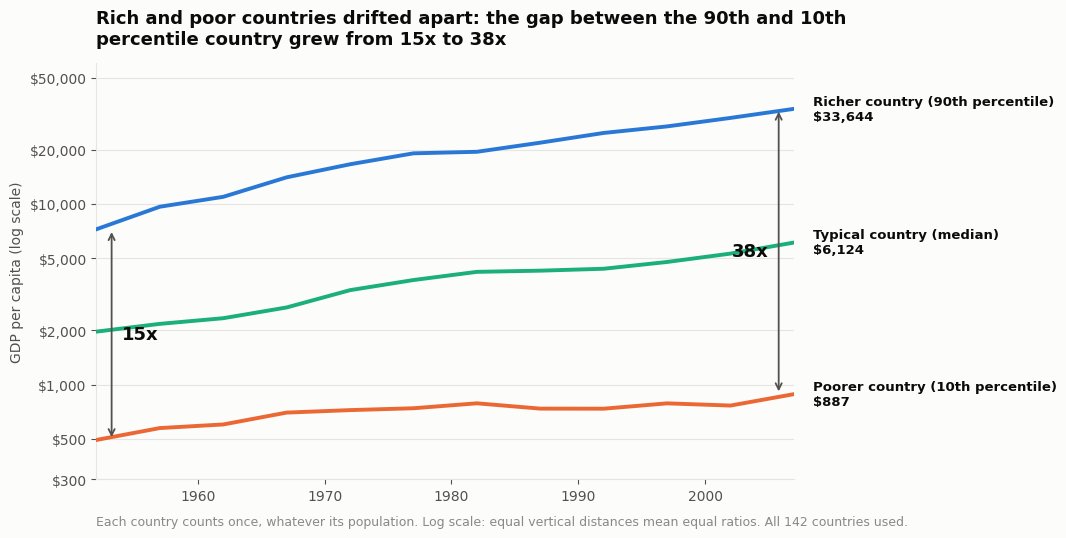

In [9]:
from matplotlib.ticker import NullLocator

r0, r1 = q.loc[1952, "ratio_p90_p10"], q.loc[2007, "ratio_p90_p10"]

fig, ax = plt.subplots(figsize=(9, 5.4))
LINES = [("p90", BLUE, "Richer country (90th percentile)"),
         ("median", AQUA, "Typical country (median)"),
         ("p10", ORANGE, "Poorer country (10th percentile)")]
for col, colour, label in LINES:
    ax.plot(q.index, q[col], color=colour, linewidth=2.8, zorder=3)
    ax.text(2008.5, q.loc[2007, col], f"{label}\n${q.loc[2007, col]:,.0f}", va="center",
            color=INK, fontsize=9.5, fontweight="bold")

# Bracket the gap at both ends - on a log axis the bracket's length IS the ratio.
for year, ratio in [(1952, r0), (2007, r1)]:
    lo, hi = q.loc[year, "p10"], q.loc[year, "p90"]
    xa = year + (1.2 if year == 1952 else -1.2)
    ax.annotate("", xy=(xa, hi), xytext=(xa, lo),
                arrowprops=dict(arrowstyle="<->", color=INK_SOFT, lw=1.3), zorder=4)
    ax.text(xa + (0.8 if year == 1952 else -0.8), np.sqrt(lo * hi), f"{ratio:.0f}x",
            ha="left" if year == 1952 else "right", va="center",
            fontsize=13, fontweight="bold", color=INK)

ax.set_yscale("log")
ax.set_yticks([300, 500, 1000, 2000, 5000, 10000, 20000, 50000])
ax.yaxis.set_major_formatter(lambda v, p: f"${v:,.0f}")
ax.yaxis.set_minor_locator(NullLocator())
ax.set_ylim(300, 60000)
ax.set_xlim(1952, 2007)
ax.set_ylabel("GDP per capita (log scale)")
ax.set_title("Rich and poor countries drifted apart: the gap between the 90th and 10th\n"
             "percentile country grew from 15x to 38x")
ax.xaxis.grid(False)
footnote(ax, "Each country counts once, whatever its population. Log scale: equal vertical distances mean "
             "equal ratios. All 142 countries used.", y=-0.11)

save(fig, "t2_income_gap")
plt.show()

**The answer is no: the gap has not narrowed, it has widened.** A country at the 90th percentile of
income was **15 times** richer than one at the 10th percentile in 1952; by 2007 it is **38 times**. In
dollars the gap grew from about $6,800 to about $32,800. The typical (median) country did get richer, from
about $2,000 to $6,100, but the top pulled away faster than the middle and the bottom barely moved
(about $500 to about $900).

**Why this chart type?** The question is a *trend over time* in a *spread*, so I need a **line chart
with time on the x-axis**. To show a spread I need more than one line, and **three percentile lines**
are the smallest set that shows "top", "middle" and "bottom" without becoming spaghetti again. The
**log y-axis** is justified above (the question is about ratios, and the data is skewed). I put the
**ratio directly on the chart** as two brackets (15x and 38x), so the reader gets the answer without
doing any arithmetic. It is a single y-axis, with no dual axis, and all three lines have direct labels.

**Two honest caveats.** (1) Extremes are noisy: the max-to-min ratio actually *fell* (about 363x to
178x) only because 1952's richest country, Kuwait, was an outlier, which is why percentiles are the more
trustworthy measure. (2) This chart treats **countries, not people**: a tiny country counts as much as
China or India. That choice changes the answer, as the next cell shows.

In [10]:
def weighted_quantile(values, weights, q):
    order = np.argsort(values.values)
    v, w = values.values[order], weights.values[order]
    cum = np.cumsum(w) / w.sum()
    return v[np.searchsorted(cum, q)]

rows = []
for year in [1952, 2007]:
    s = g[g["year"] == year]
    p10 = weighted_quantile(s["gdpPercap"], s["pop"], 0.1)
    p90 = weighted_quantile(s["gdpPercap"], s["pop"], 0.9)
    rows.append({"year": year, "p10 ($)": round(p10), "p90 ($)": round(p90), "ratio p90/p10": round(p90 / p10, 1)})
pd.DataFrame(rows).set_index("year")

,p10 ($),p90 ($),ratio p90/p10
year,,,
1952,400,9980,24.9
2007,1391,31656,22.8


**Weighted by population, the picture is different:** the 90th/10th percentile ratio is roughly **flat**
(about 25x in 1952 and about 23x in 2007). The reason is China and India: enormous populations that grew
fast, so a large share of the world's *people* moved up the income ladder even while the typical
*country* fell further behind the richest ones. So the honest, precise answer is: **between countries the
gap has widened (15x to 38x); between people it has not clearly narrowed or widened.** I chose the
country view because the question says "richest and poorest *countries*", but this is exactly the kind of
choice that should be stated, and it is why the footnote on the chart says "each country counts once".

## 7. Summary of the charts

| Chart | Type | Message |
|---|---|---|
| Spaghetti (bad) | Line, 142 series | None. Kept as an anti-example. |
| Continents | Line, 5 series, direct labels | Everyone gained; Africa stalled after 1987. |
| Highlight | Line, 3 coloured + 139 grey | A few countries reverse the trend. |
| GDP histograms | Histogram × 2 | `gdpPercap` needs a log scale. |
| Income gap | Line, 3 percentile lines, log y | Between countries, the rich-poor gap widened from 15x to 38x. |